In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
july2 = pd.read_csv('darcy_well_animation_test.csv')
july2.head()

,LAF,ST,AST,REV-ST,REV-AST,TMP,start_time,depth_m,datetime,label,leg,depth_ft
0,9.252,3450.99,3257.39,3695.13,3491.88,25.345,2026-07-02T17:01:45.975Z,0.252,01:46.0,7/2/2026 17:01,down,0.826772
1,9.506,3443.45,3219.85,3686.03,3454.46,23.719,2026-07-02T17:01:45.975Z,0.506,01:46.0,7/2/2026 17:01,down,1.660105
2,9.761,3434.73,3181.63,3677.61,3415.49,22.042,2026-07-02T17:01:45.975Z,0.761,01:46.0,7/2/2026 17:01,down,2.496719
3,10.015,3425.12,3144.08,3669.29,3376.00,20.387,2026-07-02T17:01:45.975Z,1.015,01:46.0,7/2/2026 17:01,down,3.330053
4,10.269,3418.67,3112.64,3660.58,3337.85,18.863,2026-07-02T17:01:45.975Z,1.269,01:46.0,7/2/2026 17:01,down,4.163386


In [3]:
july2.columns = july2.columns.str.strip()


In [4]:
july2["label"] = pd.to_datetime(july2["label"])
july2.head()

,LAF,ST,AST,REV-ST,REV-AST,TMP,start_time,depth_m,datetime,label,leg,depth_ft
0,9.252,3450.99,3257.39,3695.13,3491.88,25.345,2026-07-02T17:01:45.975Z,0.252,01:46.0,2026-07-02 17:01:00,down,0.826772
1,9.506,3443.45,3219.85,3686.03,3454.46,23.719,2026-07-02T17:01:45.975Z,0.506,01:46.0,2026-07-02 17:01:00,down,1.660105
2,9.761,3434.73,3181.63,3677.61,3415.49,22.042,2026-07-02T17:01:45.975Z,0.761,01:46.0,2026-07-02 17:01:00,down,2.496719
3,10.015,3425.12,3144.08,3669.29,3376.00,20.387,2026-07-02T17:01:45.975Z,1.015,01:46.0,2026-07-02 17:01:00,down,3.330053
4,10.269,3418.67,3112.64,3660.58,3337.85,18.863,2026-07-02T17:01:45.975Z,1.269,01:46.0,2026-07-02 17:01:00,down,4.163386


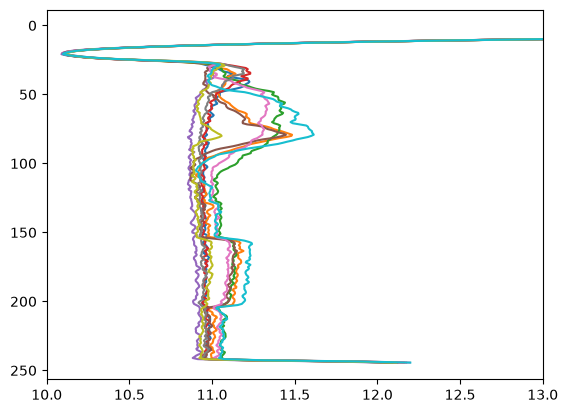

In [5]:
plt.figure()

for date, group in july2.groupby('label'):
    plt.plot(group['TMP'], group['depth_ft'], label=date.strftime('%y-%m-%d'))

plt.gca().invert_yaxis()
plt.gca().set_xlim(10, 13)

plt.show()

In [6]:
johntemp = pd.read_csv('Parish (z6-22205)(z6-22205)-Configuration 2-1784558913.2621155.csv', header=2)
johntemp.Timestamps = pd.to_datetime(johntemp.Timestamps)
johntemp.columns = johntemp.columns.str.strip()

johntemp.head()

,Timestamps,mm Water Level,WaterTempC,mS/cm EC,% Battery Percent,mV Battery Voltage,kPa Reference Pressure,degree_C Logger Temperature
0,2026-04-16 15:00:00,14878,10.3,0.617,97,7771,97.41,32.1
1,2026-04-16 15:15:00,14886,10.3,0.617,100,7816,97.37,28.3
2,2026-04-16 15:30:00,14896,10.3,0.617,100,7832,97.38,27.6
3,2026-04-16 15:45:00,14902,10.3,0.617,100,7853,97.37,28.6
4,2026-04-16 16:00:00,14905,10.3,0.615,100,7871,97.36,30.3


In [40]:
july2 = pd.read_csv('darcy_well_animation_test.csv')
july2.label = pd.to_datetime(july2.label, utc=True, errors='coerce')

In [41]:
july2['label'] = july2['label'].dt.tz_convert('America/Denver') # converting to MT because I think that is UTC-06, which is equal to America/Chicago during daylight savings time
july2.head()

,LAF,ST,AST,REV-ST,REV-AST,TMP,start_time,depth_m,datetime,label,leg,depth_ft
0,9.252,3450.99,3257.39,3695.13,3491.88,25.345,2026-07-02T17:01:45.975Z,0.252,01:46.0,2026-07-02 11:01:00-06:00,down,0.826772
1,9.506,3443.45,3219.85,3686.03,3454.46,23.719,2026-07-02T17:01:45.975Z,0.506,01:46.0,2026-07-02 11:01:00-06:00,down,1.660105
2,9.761,3434.73,3181.63,3677.61,3415.49,22.042,2026-07-02T17:01:45.975Z,0.761,01:46.0,2026-07-02 11:01:00-06:00,down,2.496719
3,10.015,3425.12,3144.08,3669.29,3376.00,20.387,2026-07-02T17:01:45.975Z,1.015,01:46.0,2026-07-02 11:01:00-06:00,down,3.330053
4,10.269,3418.67,3112.64,3660.58,3337.85,18.863,2026-07-02T17:01:45.975Z,1.269,01:46.0,2026-07-02 11:01:00-06:00,down,4.163386


In [46]:
if (70 < july2.depth_ft  < 80).any():
    print (july2.depth_ft)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

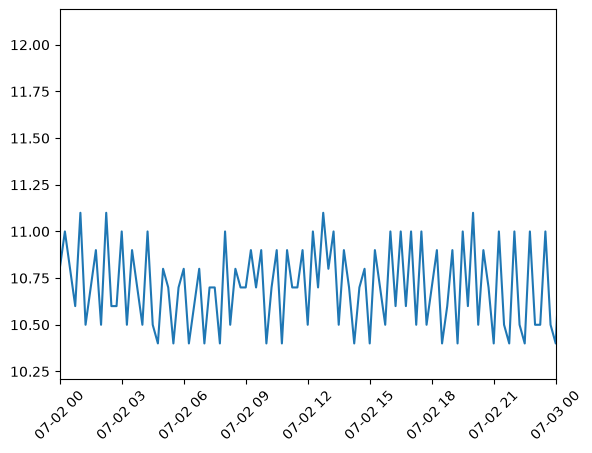

In [47]:
fig, ax = plt.subplots()

ax.plot(johntemp.Timestamps, johntemp.loc[:, 'WaterTempC'])
# ax.plot(july2.label, july2.TMP)
plt.xlim(pd.to_datetime('2026-07-02'), pd.to_datetime('2026-07-03'))
plt.xticks(rotation=45)

plt.show()